# 🧠 Parkinson's Disease Prediction — ML Pipeline + Model Export
**Dataset:** Oxford Parkinson's Disease Detection (195 rows × 22 voice features)  
**Goal:** Train the best classifier, evaluate rigorously, then save artifacts for a Streamlit app.

> **Saved files (used by Streamlit):**  
> `parkinsons_model.pkl` — trained VotingClassifier  
> `parkinsons_scaler.pkl` — RobustScaler fitted on training data  

---
**Table of Contents:**  
1. Imports · 2. Data Loading & EDA · 3. Preprocessing · 4. Feature Engineering  
5. Model Training & CV · 6. Hyperparameter Tuning · 7. Evaluation · 8. Save Artifacts

---
## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.base import clone
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier
)

try:
    from xgboost import XGBClassifier
    XGBOOST = True
except ImportError:
    XGBOOST = False

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
C_GREEN, C_RED, C_BLUE, C_ORANGE = '#4CAF50', '#F44336', '#2196F3', '#FF9800'

print(f"✅ All imports loaded  |  XGBoost: {XGBOOST}")

✅ All imports loaded  |  XGBoost: True


---
## 2. Data Loading & EDA

In [4]:
df = pd.read_csv('../datasets/parkinsons.csv')

print("=" * 60)
print(f"  Rows × Columns  : {df.shape}")
print(f"  Target balance  : {df['status'].value_counts().to_dict()}")
print(f"  Class ratio     : {df['status'].value_counts(normalize=True).round(3).to_dict()}")
print("=" * 60)
df.head()

  Rows × Columns  : (195, 24)
  Target balance  : {1: 147, 0: 48}
  Class ratio     : {1: 0.754, 0: 0.246}


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean','std']) \
    .format(precision=4)

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0000,154.2286,41.3901,88.3330,117.5720,148.7900,182.7690,260.1050
MDVP:Fhi(Hz),195.0000,197.1049,91.4915,102.1450,134.8625,175.8290,224.2055,592.0300
MDVP:Flo(Hz),195.0000,116.3246,43.5214,65.4760,84.2910,104.3150,140.0185,239.1700
MDVP:Jitter(%),195.0000,0.0062,0.0048,0.0017,0.0035,0.0049,0.0074,0.0332
MDVP:Jitter(Abs),195.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0003
MDVP:RAP,195.0000,0.0033,0.0030,0.0007,0.0017,0.0025,0.0038,0.0214
MDVP:PPQ,195.0000,0.0034,0.0028,0.0009,0.0019,0.0027,0.0040,0.0196
Jitter:DDP,195.0000,0.0099,0.0089,0.0020,0.0050,0.0075,0.0115,0.0643
MDVP:Shimmer,195.0000,0.0297,0.0189,0.0095,0.0165,0.0230,0.0379,0.1191
MDVP:Shimmer(dB),195.0000,0.2823,0.1949,0.0850,0.1485,0.2210,0.3500,1.3020


In [6]:
pd.DataFrame({
    'Dtype'     : df.dtypes,
    'Null Count': df.isnull().sum(),
    'Zero Count': (df == 0).sum(),
    'Unique'    : df.nunique()
}).style.background_gradient(cmap='OrRd', subset=['Null Count'])

,Dtype,Null Count,Zero Count,Unique
name,object,0,0,195
MDVP:Fo(Hz),float64,0,0,195
MDVP:Fhi(Hz),float64,0,0,195
MDVP:Flo(Hz),float64,0,0,195
MDVP:Jitter(%),float64,0,0,173
MDVP:Jitter(Abs),float64,0,0,19
MDVP:RAP,float64,0,0,155
MDVP:PPQ,float64,0,0,165
Jitter:DDP,float64,0,0,180
MDVP:Shimmer,float64,0,0,188


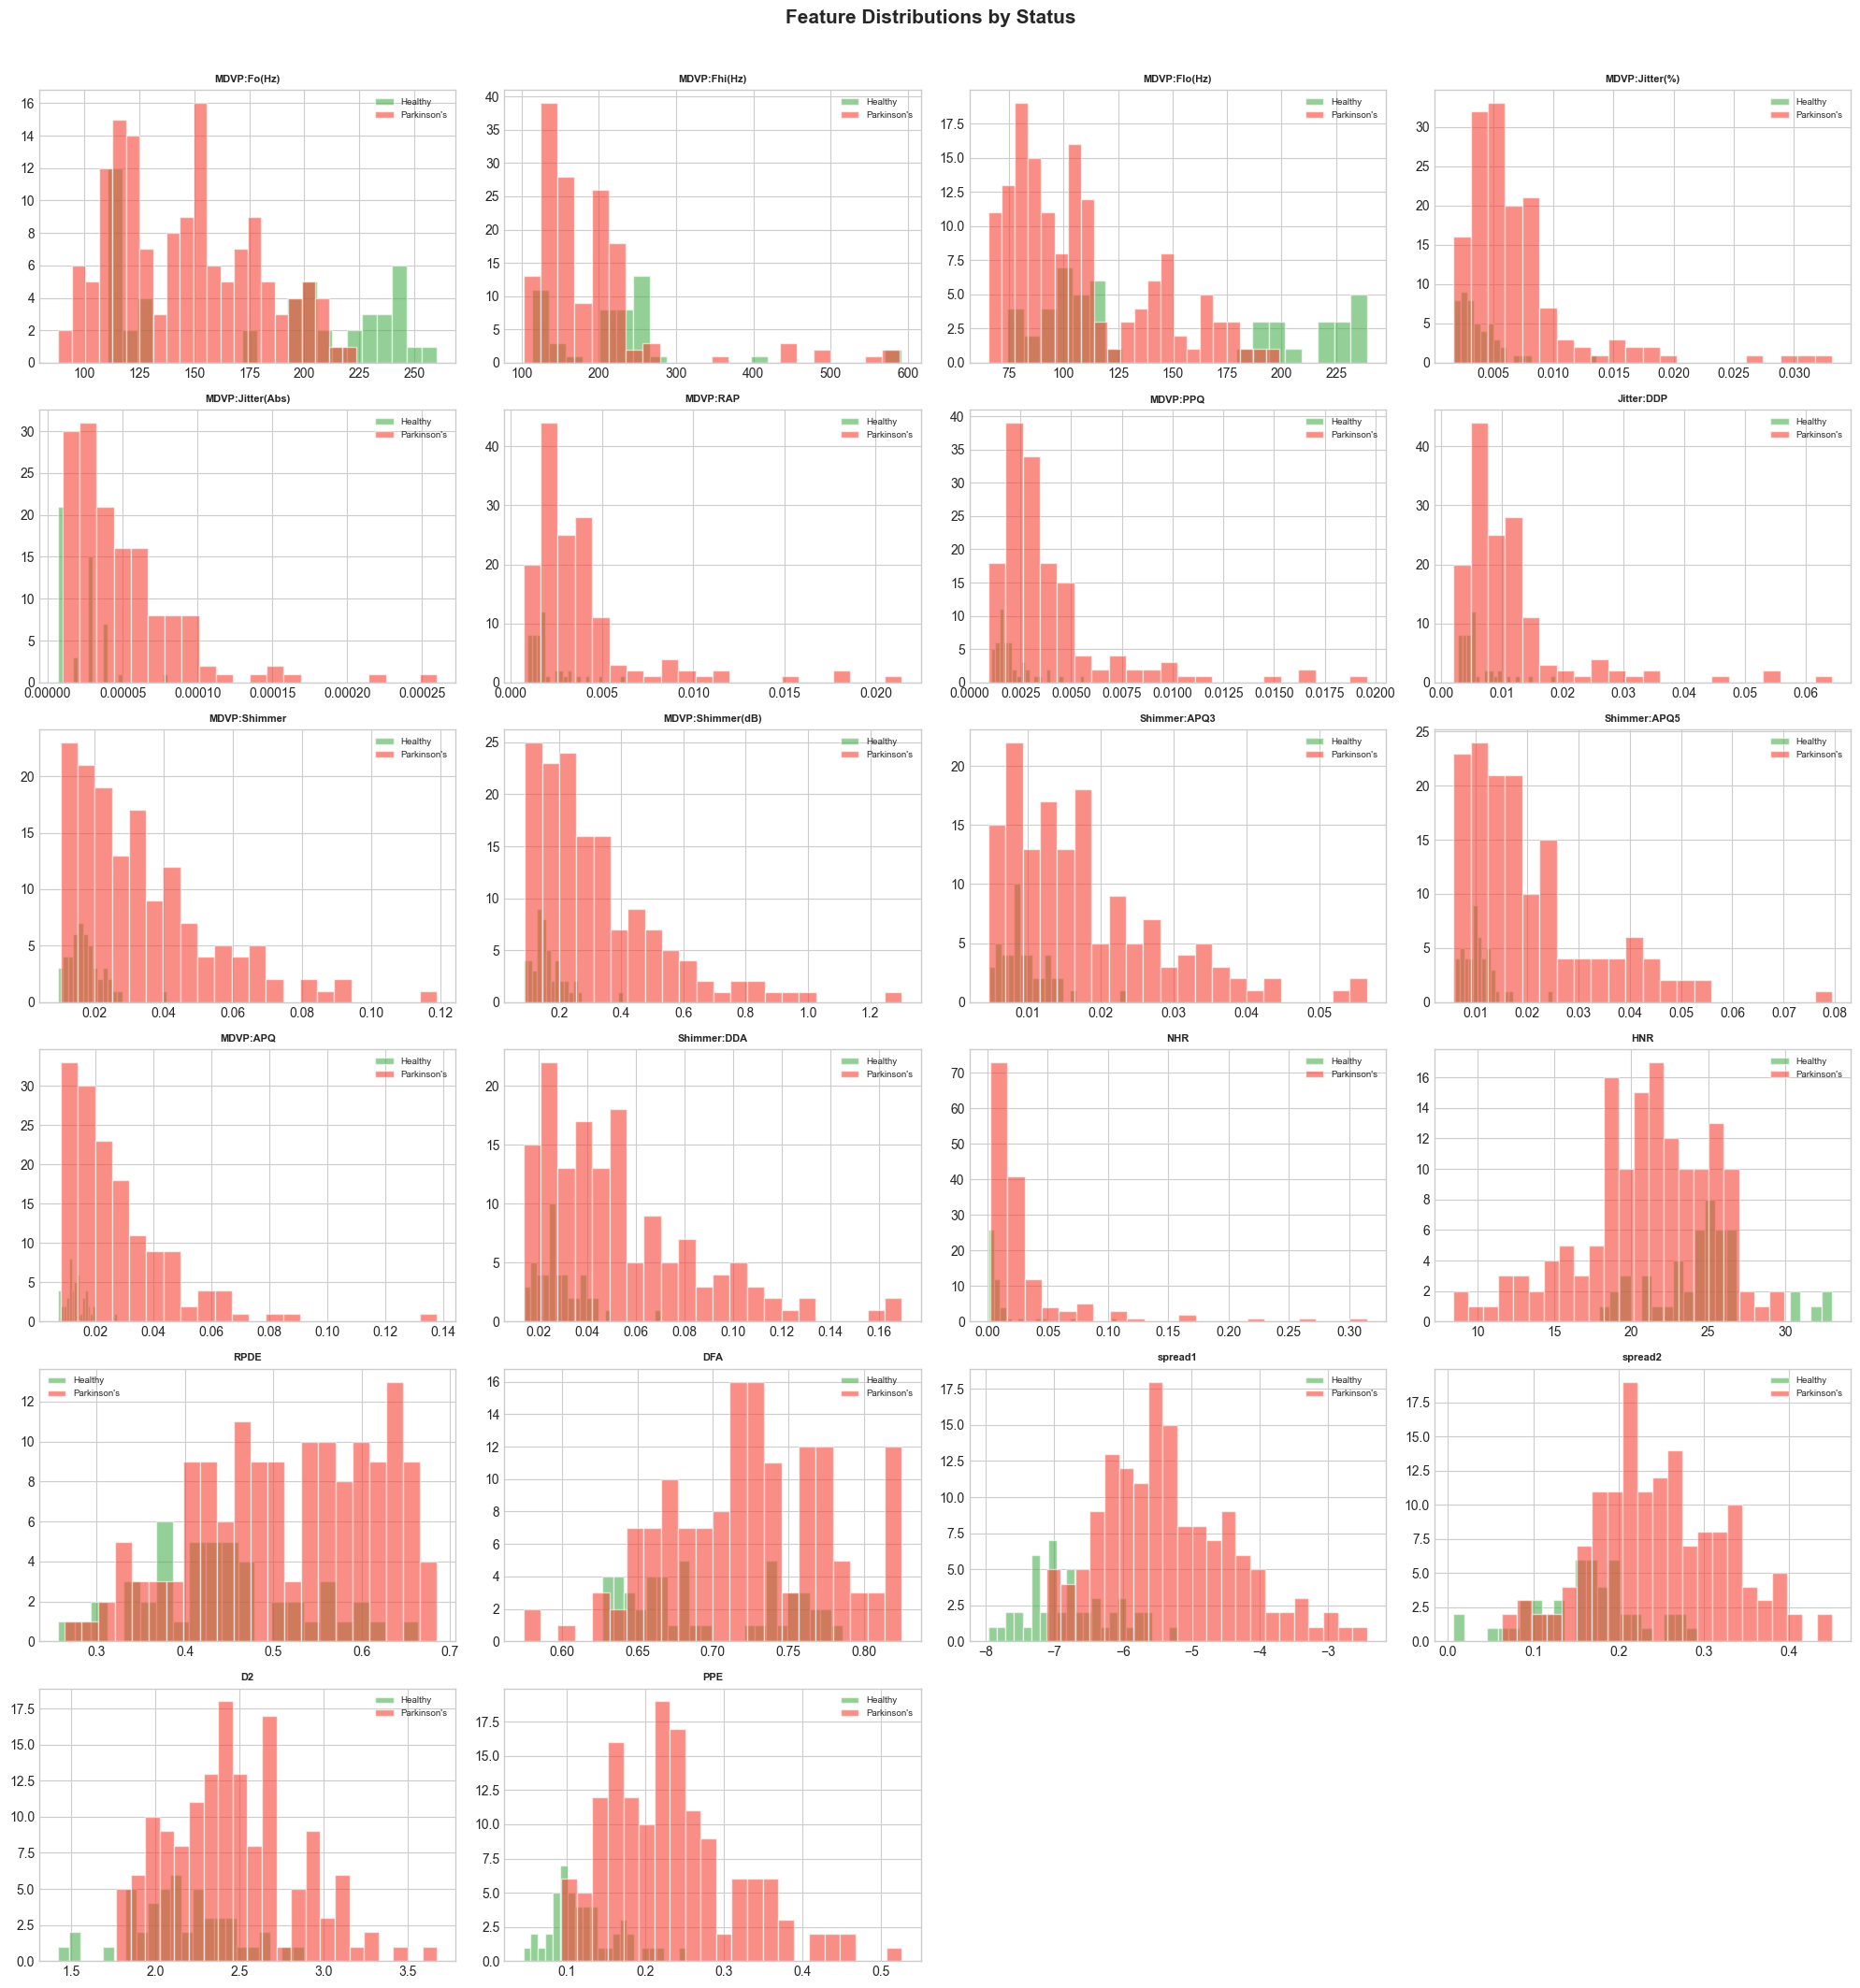

In [7]:
FEATURE_COLS = [c for c in df.columns if c not in ('name', 'status')]

n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    for status, color, lbl in zip([0, 1], [C_GREEN, C_RED], ['Healthy', "Parkinson's"]):
        axes[i].hist(df[df['status'] == status][feat], bins=22,
                     alpha=0.6, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=8)
    axes[i].legend(fontsize=7)

# Hide any spare axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Status", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

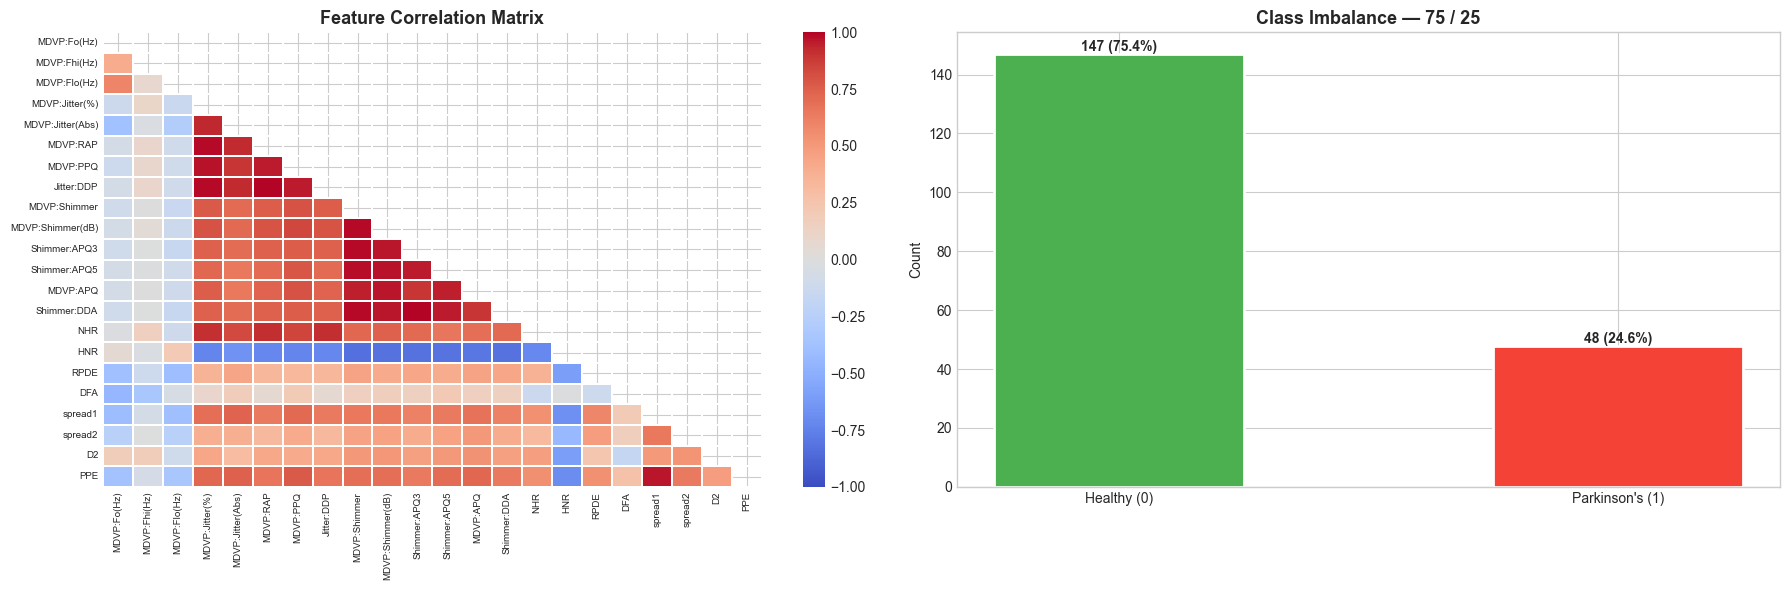

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Correlation heatmap (features only)
X_plot = df[FEATURE_COLS]
corr   = X_plot.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
axes[0].tick_params(axis='both', labelsize=7)

# Class imbalance bar chart
counts = df['status'].value_counts()
bars   = axes[1].bar(["Healthy (0)", "Parkinson's (1)"], counts,
                      color=[C_GREEN, C_RED], edgecolor='white', linewidth=2, width=0.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{count} ({count / len(df) * 100:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].set_title("Class Imbalance — 75 / 25", fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 3. Preprocessing

| Step | Technique | Reason |
|------|-----------|--------|
| Drop ID column | Remove `name` | Non-informative string identifier |
| Class balancing | Manual SMOTE (train only) | Fixes 75/25 imbalance — minority is *Healthy* class |
| Outlier capping | IQR × 1.5 | Clips extremes without deleting any rows |
| Scaling | RobustScaler | Median + IQR — robust to residual outliers |

In [9]:
# Drop the non-informative name column
X = df.drop(columns=['name', 'status'])
y = df['status']

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\n→ Minority class = Healthy (0) | {(y==0).sum()} samples")

Features : 22
Samples  : 195

Class distribution:
status
1    147
0     48
Name: count, dtype: int64

→ Minority class = Healthy (0) | 48 samples


In [10]:
def cap_outliers(df_in, factor=1.5):
    df2 = df_in.copy()
    for col in df2.columns:
        Q1, Q3 = df2[col].quantile([0.25, 0.75])
        IQR    = Q3 - Q1
        n_out  = ((df2[col] < Q1 - factor * IQR) | (df2[col] > Q3 + factor * IQR)).sum()
        df2[col] = df2[col].clip(Q1 - factor * IQR, Q3 + factor * IQR)
        if n_out > 0:
            print(f"  {col:<28}: {n_out} outliers capped")
    return df2

X_capped = cap_outliers(X)
print("\n✅ Outlier capping complete")

  MDVP:Fhi(Hz)                : 11 outliers capped
  MDVP:Flo(Hz)                : 9 outliers capped
  MDVP:Jitter(%)              : 14 outliers capped
  MDVP:Jitter(Abs)            : 7 outliers capped
  MDVP:RAP                    : 14 outliers capped
  MDVP:PPQ                    : 15 outliers capped
  Jitter:DDP                  : 14 outliers capped
  MDVP:Shimmer                : 8 outliers capped
  MDVP:Shimmer(dB)            : 10 outliers capped
  Shimmer:APQ3                : 6 outliers capped
  Shimmer:APQ5                : 13 outliers capped
  MDVP:APQ                    : 12 outliers capped
  Shimmer:DDA                 : 6 outliers capped
  NHR                         : 19 outliers capped
  HNR                         : 3 outliers capped
  spread1                     : 4 outliers capped
  spread2                     : 2 outliers capped
  D2                          : 1 outliers capped
  PPE                         : 5 outliers capped

✅ Outlier capping complete


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_capped, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train balance : {dict(y_train.value_counts())}")
print(f"Test  balance : {dict(y_test.value_counts())}")

Train : (156, 22)  |  Test : (39, 22)
Train balance : {1: 118, 0: 38}
Test  balance : {1: 29, 0: 10}


In [12]:
def manual_smote(X, y, k=5, seed=42):
    """Oversample minority class via KNN interpolation."""
    rng = np.random.default_rng(seed)
    X, y = np.array(X, dtype=float), np.array(y)
    classes, counts = np.unique(y, return_counts=True)
    minority  = classes[np.argmin(counts)]
    n_gen     = counts.max() - counts.min()
    X_min     = X[y == minority]
    nn        = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    _, idxs   = nn.kneighbors(X_min)
    synthetic = [
        X_min[i % len(X_min)] +
        rng.random() * (X_min[idxs[i % len(X_min), rng.integers(1, k + 1)]] -
                        X_min[i % len(X_min)])
        for i in range(n_gen)
    ]
    X_res = np.vstack([X, np.vstack(synthetic)])
    y_res = np.concatenate([y, np.full(n_gen, minority)])
    perm  = rng.permutation(len(y_res))
    return X_res[perm], y_res[perm]

X_train_sm, y_train_sm = manual_smote(X_train.values, y_train.values)
print(f"Before SMOTE : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After  SMOTE : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")

Before SMOTE : {0: 38, 1: 118}
After  SMOTE : {0: 118, 1: 118}


In [13]:
scaler      = RobustScaler()
X_train_sc  = scaler.fit_transform(X_train_sm)
X_test_sc   = scaler.transform(X_test)
print(f"✅ Scaling done | Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

✅ Scaling done | Train: (236, 22) | Test: (39, 22)


---
## 4. Feature Engineering

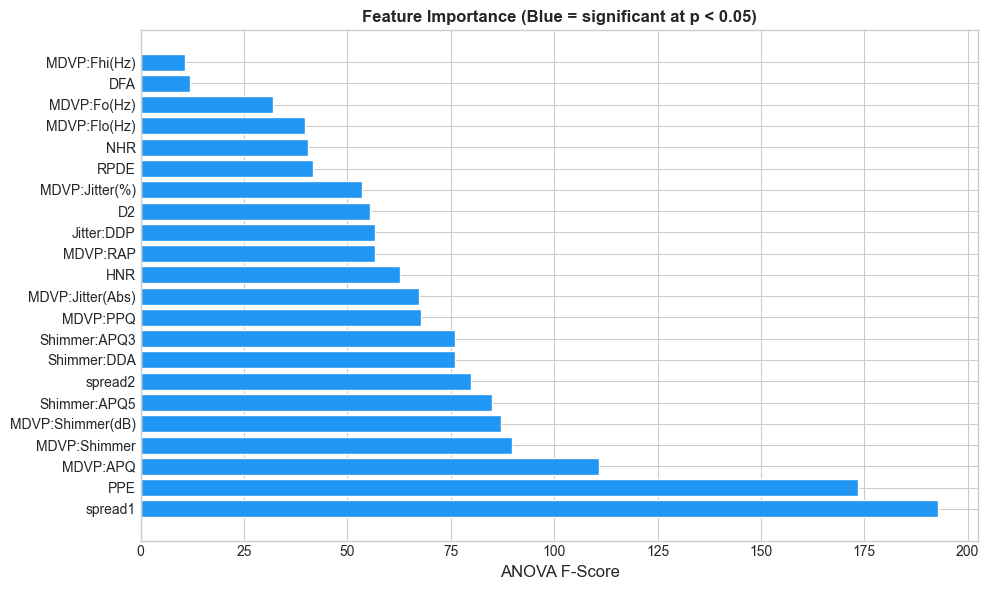

         Feature    F-Score      p-value
         spread1 192.940129 2.150083e-32
             PPE 173.509857 5.151373e-30
        MDVP:APQ 110.859615 1.793092e-21
    MDVP:Shimmer  89.874594 2.983537e-18
MDVP:Shimmer(dB)  87.204337 7.943559e-18
    Shimmer:APQ5  84.889795 1.869088e-17
         spread2  79.849938 1.232059e-16
     Shimmer:DDA  76.041457 5.232441e-16
    Shimmer:APQ3  76.037125 5.241112e-16
        MDVP:PPQ  67.709081 1.323151e-14
MDVP:Jitter(Abs)  67.423617 1.480456e-14
             HNR  62.718217 9.587606e-14
        MDVP:RAP  56.684036 1.102891e-12
      Jitter:DDP  56.676490 1.106303e-12
              D2  55.488598 1.800994e-12
  MDVP:Jitter(%)  53.579788 3.958914e-12
            RPDE  41.634955 6.261172e-10
             NHR  40.513726 1.019902e-09
    MDVP:Flo(Hz)  39.759564 1.417908e-09
     MDVP:Fo(Hz)  32.097700 4.286260e-08
             DFA  11.958348 6.461720e-04
    MDVP:Fhi(Hz)  10.753038 1.199619e-03


In [14]:
# ANOVA F-test on base features
sel  = SelectKBest(f_classif, k='all').fit(X_train_sc, y_train_sm)
fimp = pd.DataFrame({
    'Feature': X_capped.columns,
    'F-Score': sel.scores_,
    'p-value': sel.pvalues_
}).sort_values('F-Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
clrs = [C_BLUE if p < 0.05 else '#BDBDBD' for p in fimp['p-value']]
ax.barh(fimp['Feature'], fimp['F-Score'], color=clrs, edgecolor='white')
ax.set_xlabel('ANOVA F-Score', fontsize=12)
ax.set_title('Feature Importance (Blue = significant at p < 0.05)', fontweight='bold')
plt.tight_layout()
plt.show()
print(fimp.to_string(index=False))

In [15]:
def add_features(df_in):
    """Biomedically motivated interaction / polynomial features."""
    df2 = df_in.copy()
    # Jitter interaction
    df2['Jitter_RAP_x_PPQ']  = df2['MDVP:RAP']  * df2['MDVP:PPQ']
    # Shimmer interaction
    df2['Shimmer_APQ3_x_APQ5'] = df2['Shimmer:APQ3'] * df2['Shimmer:APQ5']
    # HNR / NHR ratio (voice quality)
    df2['HNR_NHR_ratio']     = df2['HNR'] / (df2['NHR'] + 1e-8)
    # Nonlinear dynamics
    df2['RPDE_x_DFA']        = df2['RPDE'] * df2['DFA']
    df2['spread1_x_spread2'] = df2['spread1'] * df2['spread2']
    df2['PPE_squared']       = df2['PPE'] ** 2
    df2['D2_squared']        = df2['D2'] ** 2
    # Fo range
    df2['Fo_range']          = df2['MDVP:Fhi(Hz)'] - df2['MDVP:Flo(Hz)']
    return df2

X_fe = cap_outliers(add_features(X_capped))
print(f"Feature count: {X_capped.shape[1]} → {X_fe.shape[1]}")

# Rebuild full pipeline with engineered features
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.20, random_state=42, stratify=y
)
X_tr_sm, y_tr_sm = manual_smote(X_train_fe.values, y_train_fe.values)

scaler_fe = RobustScaler()
X_tr_sc   = scaler_fe.fit_transform(X_tr_sm)
X_te_sc   = scaler_fe.transform(X_test_fe)
print(f"✅ Pipeline rebuilt | Train: {X_tr_sc.shape} | Test: {X_te_sc.shape}")

  Jitter_RAP_x_PPQ            : 18 outliers capped
  Shimmer_APQ3_x_APQ5         : 22 outliers capped
  HNR_NHR_ratio               : 12 outliers capped
  spread1_x_spread2           : 13 outliers capped
  PPE_squared                 : 14 outliers capped
  D2_squared                  : 3 outliers capped
  Fo_range                    : 10 outliers capped
Feature count: 22 → 30
✅ Pipeline rebuilt | Train: (236, 30) | Test: (39, 30)


---
## 5. Model Training — 10 Classifiers (10-fold Stratified CV)

In [16]:
models = {
    'Logistic Regression'    : LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Naive Bayes'            : GaussianNB(),
    'Linear Discriminant'    : LinearDiscriminantAnalysis(),
    'Decision Tree'          : DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, random_state=42),
    'Support Vector Machine' : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'AdaBoost'               : AdaBoostClassifier(n_estimators=250, learning_rate=0.05, random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=700, min_samples_leaf=2,
                                   class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'Extra Trees'            : ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2,
                                   class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=300, learning_rate=0.03,
                                   max_depth=3, subsample=0.9, random_state=42),
}
if XGBOOST:
    models['XGBoost'] = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        min_child_weight=2, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.5, eval_metric='logloss', random_state=42
    )

print(f"✅ {len(models)} models configured")

✅ 11 models configured


In [17]:
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results  = {}

print(f"{'Model':<28} {'CV Acc':>9} {'±Std':>7} {'Test Acc':>10} {'F1':>7} {'AUC':>8}")
print('─' * 73)

for name, model in models.items():
    cv_s = cross_val_score(model, X_tr_sc, y_tr_sm, cv=cv_strat,
                           scoring='accuracy', n_jobs=-1)
    model.fit(X_tr_sc, y_tr_sm)
    yp   = model.predict(X_te_sc)
    ypr  = model.predict_proba(X_te_sc)[:, 1] if hasattr(model, 'predict_proba') else None
    ta   = accuracy_score(y_test_fe, yp)
    f1   = f1_score(y_test_fe, yp)
    auc  = roc_auc_score(y_test_fe, ypr) if ypr is not None else 0.0
    results[name] = dict(model=model, cv_mean=cv_s.mean(), cv_std=cv_s.std(),
                         test_acc=ta, f1=f1, auc=auc, y_pred=yp, y_proba=ypr)
    print(f"{name:<28} {cv_s.mean():>9.4f} {cv_s.std():>7.4f} {ta:>10.4f} {f1:>7.4f} {auc:>8.4f}")

print('─' * 73)
print(f"Best by CV  : {max(results, key=lambda k: results[k]['cv_mean'])}")
print(f"Best by Test: {max(results, key=lambda k: results[k]['test_acc'])}")

Model                           CV Acc    ±Std   Test Acc      F1      AUC
─────────────────────────────────────────────────────────────────────────
Logistic Regression             0.8734  0.0754     0.7949  0.8519   0.9310
K-Nearest Neighbors             0.9027  0.0571     0.7949  0.8400   1.0000
Naive Bayes                     0.7973  0.1074     0.6667  0.7234   0.8517
Linear Discriminant             0.8775  0.0692     0.8462  0.8889   0.8966
Decision Tree                   0.8732  0.0760     0.8205  0.8627   0.9500
Support Vector Machine          0.9275  0.0587     0.8718  0.9091   0.9483
AdaBoost                        0.8774  0.0769     0.7692  0.8302   0.8759
Random Forest                   0.9112  0.0695     0.8205  0.8727   0.9517
Extra Trees                     0.9107  0.0787     0.9231  0.9474   0.9793
Gradient Boosting               0.9152  0.0717     0.9487  0.9655   0.9897
XGBoost                         0.9237  0.0681     0.9487  0.9655   0.9862
──────────────────────────

---
## 6. Hyperparameter Tuning (RandomizedSearchCV, 50 iter, 5-fold)

In [18]:
param_grids = {
    'Random Forest': {
        'n_estimators'    : [300, 500, 700, 900],
        'max_depth'       : [None, 8, 12, 16],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features'    : ['sqrt', 'log2'],
        'class_weight'    : ['balanced', 'balanced_subsample'],
    },
    'Extra Trees': {
        'n_estimators'    : [300, 500, 700, 900],
        'max_depth'       : [None, 8, 12],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features'    : ['sqrt', 'log2'],
        'class_weight'    : ['balanced', 'balanced_subsample'],
    },
    'Gradient Boosting': {
        'n_estimators' : [150, 250, 350, 500],
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth'    : [2, 3, 4],
        'subsample'    : [0.7, 0.85, 1.0],
    },
    'Support Vector Machine': {
        'C'          : [0.5, 1, 5, 10, 20, 50],
        'gamma'      : ['scale', 'auto', 0.1, 0.01, 0.001],
        'kernel'     : ['rbf'],
        'probability': [True],
    },
}
if XGBOOST:
    param_grids['XGBoost'] = {
        'n_estimators'    : [300, 500, 700],
        'max_depth'       : [3, 4, 5],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
        'reg_alpha'       : [0.0, 0.1, 0.5],
        'reg_lambda'      : [1.0, 1.5, 2.0],
    }

results_df = pd.DataFrame([
    {'Model': k, 'CV Mean': v['cv_mean'], 'Test Acc': v['test_acc'],
     'F1': v['f1'], 'AUC': v['auc']}
    for k, v in results.items()
]).sort_values('CV Mean', ascending=False).reset_index(drop=True)

to_tune = [m for m in results_df['Model'].tolist() if m in param_grids][:5]
print(f"Models selected for tuning: {to_tune}")

Models selected for tuning: ['Support Vector Machine', 'XGBoost', 'Gradient Boosting', 'Random Forest', 'Extra Trees']


In [19]:
tuned    = {}
tune_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in to_tune:
    print(f"\n🔧 Tuning {name} ...")
    estimator = clone(results[name]['model'])
    if isinstance(estimator, SVC):
        estimator.set_params(probability=True)

    search = RandomizedSearchCV(
        estimator, param_grids[name], n_iter=50,
        cv=tune_cv, scoring='accuracy', n_jobs=-1,
        random_state=42, verbose=0
    )
    search.fit(X_tr_sc, y_tr_sm)
    bm   = search.best_estimator_
    yp   = bm.predict(X_te_sc)
    ypr  = bm.predict_proba(X_te_sc)[:, 1]
    tuned[name] = dict(
        model      = bm,
        best_params= search.best_params_,
        cv_score   = search.best_score_,
        test_acc   = accuracy_score(y_test_fe, yp),
        f1         = f1_score(y_test_fe, yp),
        auc        = roc_auc_score(y_test_fe, ypr),
        y_pred     = yp,
        y_proba    = ypr
    )
    print(f"   CV={search.best_score_:.4f}  Test={tuned[name]['test_acc']:.4f}  AUC={tuned[name]['auc']:.4f}")
    print(f"   {search.best_params_}")


🔧 Tuning Support Vector Machine ...
   CV=0.9405  Test=0.9231  AUC=0.9621
   {'probability': True, 'kernel': 'rbf', 'gamma': 'scale', 'C': 50}

🔧 Tuning XGBoost ...
   CV=0.9451  Test=0.9487  AUC=0.9828
   {'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

🔧 Tuning Gradient Boosting ...
   CV=0.9491  Test=0.9487  AUC=0.9931
   {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.1}

🔧 Tuning Random Forest ...
   CV=0.9156  Test=0.8462  AUC=0.9448
   {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 16, 'class_weight': 'balanced_subsample'}

🔧 Tuning Extra Trees ...
   CV=0.9322  Test=0.9231  AUC=0.9828
   {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced'}


In [20]:
print("\n🤝 Building Soft Voting Ensemble ...")
voting_clf = VotingClassifier(
    estimators=[(n, v['model']) for n, v in tuned.items()],
    voting='soft', n_jobs=-1
)
voting_clf.fit(X_tr_sc, y_tr_sm)
yv   = voting_clf.predict(X_te_sc)
yprv = voting_clf.predict_proba(X_te_sc)[:, 1]

tuned['Voting Ensemble'] = dict(
    model    = voting_clf,
    cv_score = 0,
    test_acc = accuracy_score(y_test_fe, yv),
    f1       = f1_score(y_test_fe, yv),
    auc      = roc_auc_score(y_test_fe, yprv),
    y_pred   = yv,
    y_proba  = yprv
)
print(f"   Test Accuracy : {tuned['Voting Ensemble']['test_acc']:.4f}")
print(f"   AUC-ROC       : {tuned['Voting Ensemble']['auc']:.4f}")


🤝 Building Soft Voting Ensemble ...
   Test Accuracy : 0.9487
   AUC-ROC       : 0.9862


---
## 7. Evaluation & Comparison

In [21]:
rows = (
    [{'Model': k,       'Type': 'Baseline', 'CV Acc': v['cv_mean'],
      'Test Acc': v['test_acc'], 'F1': v['f1'], 'AUC': v['auc']}
     for k, v in results.items()]
  + [{'Model': k + ' ★', 'Type': 'Tuned', 'CV Acc': v.get('cv_score', 0),
      'Test Acc': v['test_acc'], 'F1': v['f1'], 'AUC': v['auc']}
     for k, v in tuned.items()]
)
cmp = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
cmp.style \
    .background_gradient(subset=['Test Acc', 'F1', 'AUC'], cmap='RdYlGn') \
    .format({'CV Acc': '{:.4f}', 'Test Acc': '{:.4f}', 'F1': '{:.4f}', 'AUC': '{:.4f}'}) \
    .set_properties(**{'font-size': '11px'})

,Model,Type,CV Acc,Test Acc,F1,AUC
0,Voting Ensemble ★,Tuned,0.0000,0.9487,0.9655,0.9862
1,Gradient Boosting,Baseline,0.9152,0.9487,0.9655,0.9897
2,Gradient Boosting ★,Tuned,0.9491,0.9487,0.9655,0.9931
3,XGBoost ★,Tuned,0.9451,0.9487,0.9655,0.9828
4,XGBoost,Baseline,0.9237,0.9487,0.9655,0.9862
5,Extra Trees ★,Tuned,0.9322,0.9231,0.9474,0.9828
6,Support Vector Machine ★,Tuned,0.9405,0.9231,0.9474,0.9621
7,Extra Trees,Baseline,0.9107,0.9231,0.9474,0.9793
8,Support Vector Machine,Baseline,0.9275,0.8718,0.9091,0.9483
9,Linear Discriminant,Baseline,0.8775,0.8462,0.8889,0.8966


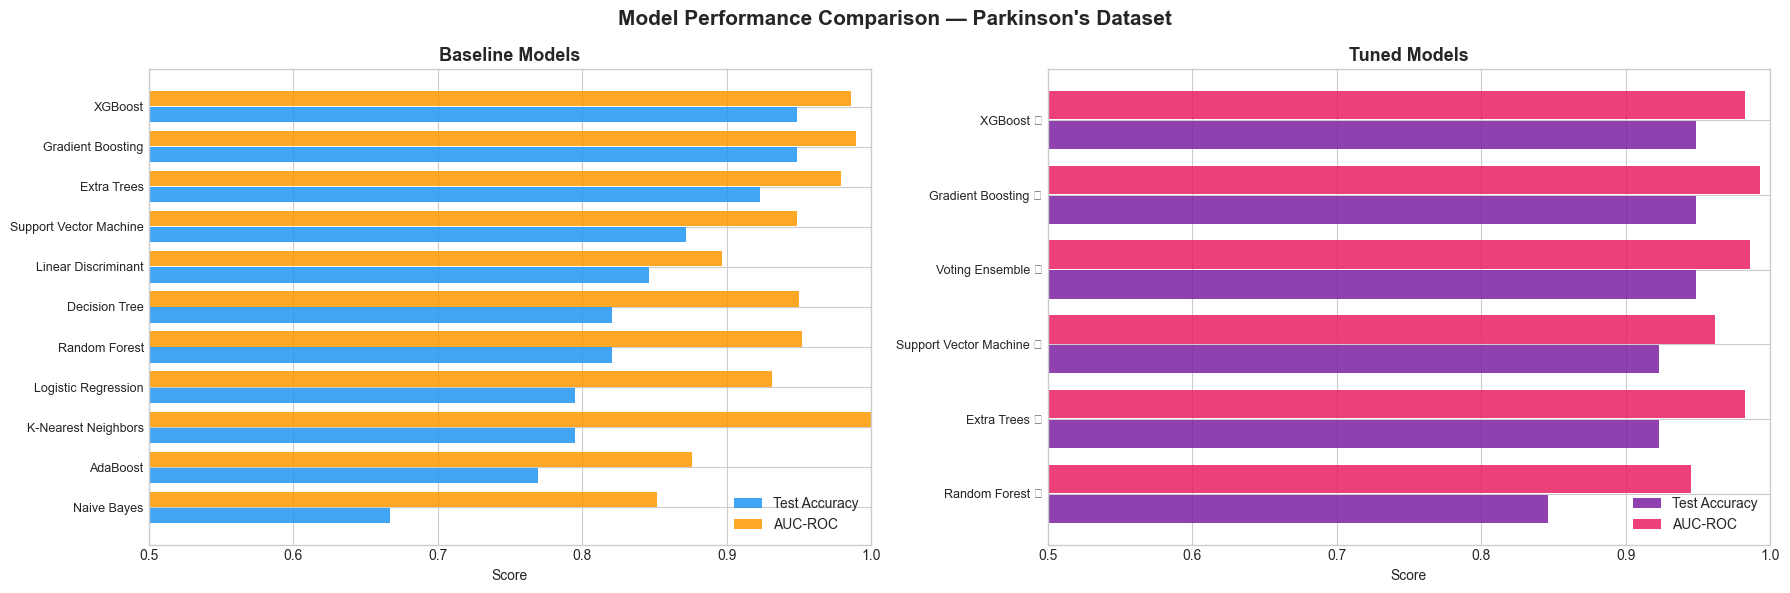

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, mask, title, c1, c2 in [
    (axes[0], 'Baseline', 'Baseline Models',  C_BLUE,    C_ORANGE),
    (axes[1], 'Tuned',    'Tuned Models',     '#7B1FA2', '#E91E63'),
]:
    data = cmp[cmp['Type'] == mask].sort_values('Test Acc', ascending=True)
    x    = np.arange(len(data))
    ax.barh(x - 0.2, data['Test Acc'], 0.38, label='Test Accuracy', color=c1,  alpha=0.85)
    ax.barh(x + 0.2, data['AUC'],      0.38, label='AUC-ROC',       color=c2,  alpha=0.85)
    ax.set_yticks(x); ax.set_yticklabels(data['Model'], fontsize=9)
    ax.set_xlim(0.5, 1.0); ax.set_xlabel('Score')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.legend(loc='lower right')
plt.suptitle("Model Performance Comparison — Parkinson's Dataset",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

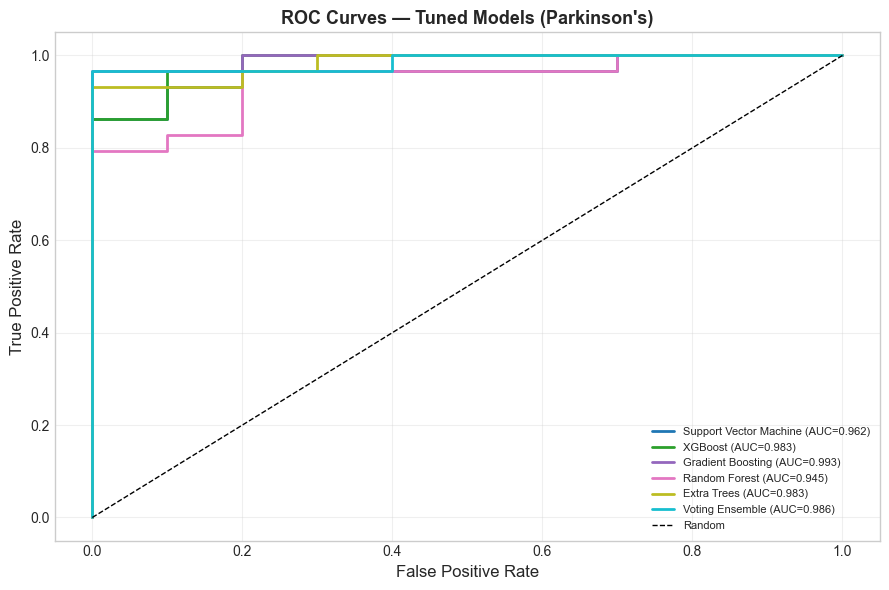

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
palette  = plt.cm.tab10(np.linspace(0, 1, len(tuned)))
for (name, v), color in zip(tuned.items(), palette):
    fpr, tpr, _ = roc_curve(y_test_fe, v['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.3f})", linewidth=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title("ROC Curves — Tuned Models (Parkinson's)", fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
best_name = max(tuned, key=lambda k: tuned[k]['test_acc'])
best      = tuned[best_name]

print("=" * 60)
print(f"  BEST MODEL    : {best_name}")
print(f"  Test Accuracy : {best['test_acc']:.4f}  ({best['test_acc'] * 100:.2f}%)")
print(f"  F1 Score      : {best['f1']:.4f}")
print(f"  AUC-ROC       : {best['auc']:.4f}")
print("=" * 60)
print()
print(classification_report(y_test_fe, best['y_pred'],
                             target_names=["Healthy", "Parkinson's"]))

  BEST MODEL    : XGBoost
  Test Accuracy : 0.9487  (94.87%)
  F1 Score      : 0.9655
  AUC-ROC       : 0.9828

              precision    recall  f1-score   support

     Healthy       0.90      0.90      0.90        10
 Parkinson's       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



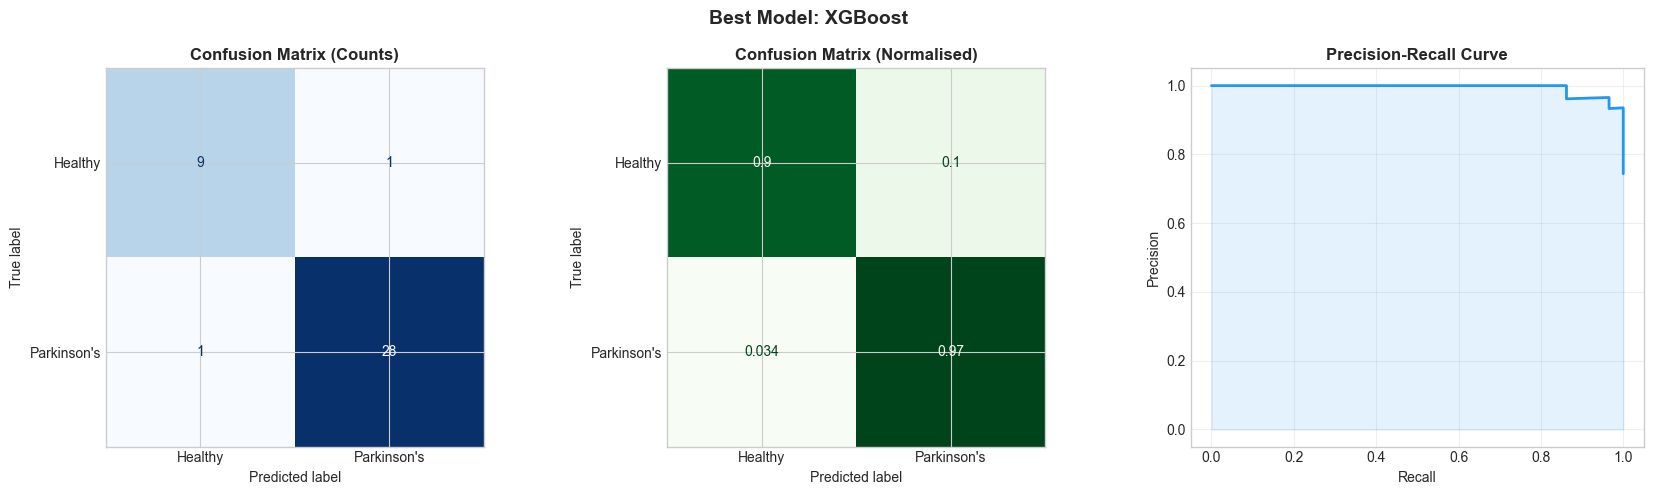

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cm = confusion_matrix(y_test_fe, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Parkinson's"]).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=["Healthy", "Parkinson's"]).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

prec, rec, _ = precision_recall_curve(y_test_fe, best['y_proba'])
axes[2].plot(rec, prec, color=C_BLUE, linewidth=2)
axes[2].fill_between(rec, prec, alpha=0.12, color=C_BLUE)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

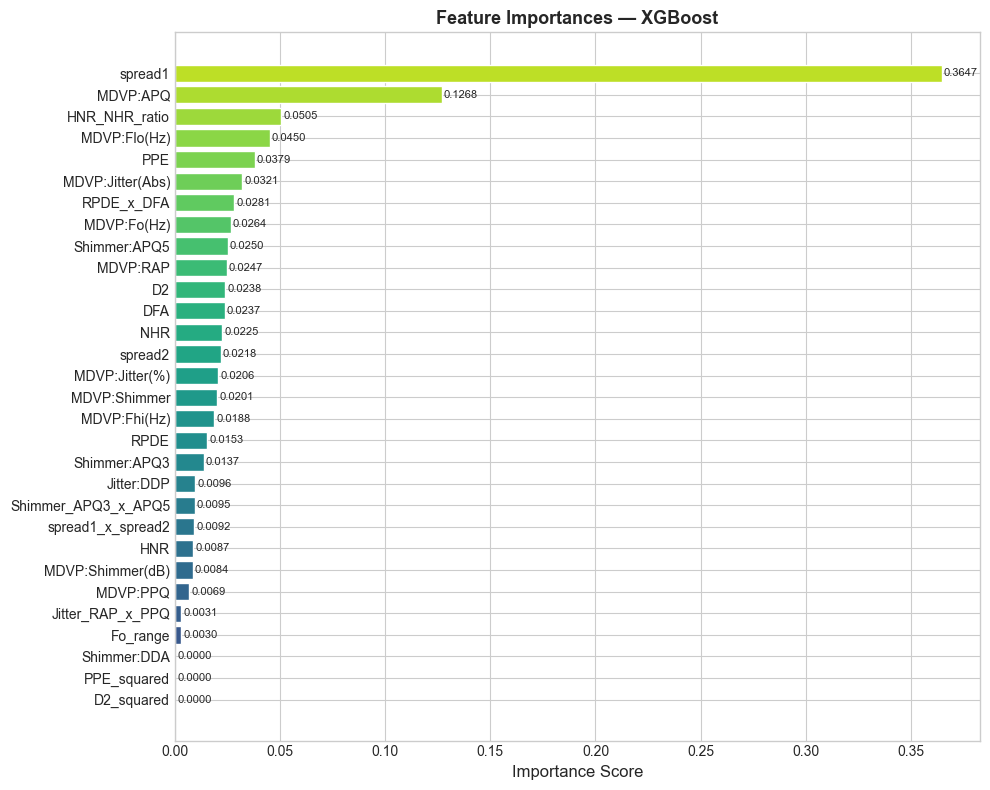

In [26]:
if hasattr(best['model'], 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature'  : X_fe.columns,
        'Importance': best['model'].feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    clr  = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_df)))
    bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=clr, edgecolor='white')
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f"Feature Importances — {best_name}", fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 8. Save Artifacts for Streamlit

> Two files are saved here and loaded directly by the Streamlit app:  
> - `parkinsons_model.pkl` — the best trained classifier  
> - `parkinsons_scaler.pkl` — RobustScaler (fitted on SMOTE-augmented train set with engineered features)  
>
> The Streamlit app must apply them **in order**: cap_outliers → add_features → scale → predict.

In [27]:
joblib.dump(best['model'], '../models/parkinsons_model.pkl')
joblib.dump(scaler_fe,      '../models/parkinsons_scaler.pkl')

print("✅ Saved:")
print("   parkinsons_model.pkl   — best classifier")
print("   parkinsons_scaler.pkl  — RobustScaler (30 features after engineering)")

# Verify round-trip
model_ld  = joblib.load('../models/parkinsons_model.pkl')
scaler_ld = joblib.load('../models/parkinsons_scaler.pkl')
acc_v     = accuracy_score(y_test_fe, model_ld.predict(X_te_sc))
print(f"\n✅ Verification — loaded model test accuracy: {acc_v:.4f}")

✅ Saved:
   parkinsons_model.pkl   — best classifier
   parkinsons_scaler.pkl  — RobustScaler (30 features after engineering)

✅ Verification — loaded model test accuracy: 0.9487


In [28]:
# ── End-to-end prediction function (mirrors Streamlit app logic) ──────────
FEATURE_COLS = list(X.columns)   # 22 base voice features

def predict_parkinsons(patient: dict) -> dict:
    """
    End-to-end prediction for a single patient.
    This function can be copy-pasted into the Streamlit app.

    Parameters
    ----------
    patient : dict  — keys must match FEATURE_COLS (22 base voice features)

    Returns
    -------
    dict with Prediction, Probability, Risk Level, and Model name
    """
    df_p = pd.DataFrame([patient], columns=FEATURE_COLS)
    # 1. Outlier capping
    df_c = cap_outliers(df_p)
    # 2. Feature engineering (must match training exactly)
    df_e = add_features(df_c)
    # 3. Scale
    df_s = scaler_ld.transform(df_e)
    # 4. Predict
    pred = model_ld.predict(df_s)[0]
    prob = model_ld.predict_proba(df_s)[0][1]
    risk = 'HIGH' if prob >= 0.6 else ('MODERATE' if prob >= 0.35 else 'LOW')
    return {
        'Prediction' : "Parkinson's Positive" if pred == 1 else 'Healthy',
        'Probability': f'{prob * 100:.1f}%',
        'Risk Level' : risk,
        'Model'      : best_name,
    }

# Test on two known rows from the dataset
sample_pos = dict(zip(FEATURE_COLS,
    [197.076, 206.896, 192.055, 0.00289, 0.00001, 0.00166,
     0.00168, 0.00498, 0.01098, 0.097,   0.00563, 0.0068,
     0.00802, 0.01689, 0.00339, 26.775,  0.422229, 0.741367,
    -7.3483, 0.177551, 1.743867, 0.085569]))

sample_neg = dict(zip(FEATURE_COLS,
    [119.992, 157.302, 74.997, 0.00784, 0.00007, 0.0037,
     0.00554, 0.01109, 0.04374, 0.426,   0.02182, 0.0313,
     0.02971, 0.06545, 0.09387, 21.033,  0.414783, 0.815285,
    -4.8130, 0.266482, 2.301442, 0.284654]))

for label, pt in [("Parkinson's Positive sample", sample_pos),
                  ("Healthy sample",              sample_neg)]:
    r = predict_parkinsons(pt)
    print(f"\n{label}")
    for k, v in r.items():
        print(f"   {k:<14}: {v}")


Parkinson's Positive sample
   Prediction    : Healthy
   Probability   : 3.2%
   Risk Level    : LOW
   Model         : XGBoost

Healthy sample
   Prediction    : Parkinson's Positive
   Probability   : 99.7%
   Risk Level    : HIGH
   Model         : XGBoost


---
## Summary

| Stage | Technique | Key Decision |
|-------|-----------|-------------|
| ID removal | Drop `name` column | Non-informative string identifier |
| Class imbalance | Manual SMOTE — train only | Minority = Healthy (0); 75/25 split |
| Outliers | IQR × 1.5 capping | Clips extremes without deleting rows |
| Scaling | RobustScaler | Median + IQR — robust to remaining outliers |
| Feature engineering | 8 interaction terms (Jitter, Shimmer, HNR/NHR, RPDE×DFA, etc.) | Captures non-linear voice biomarker interactions |
| Model selection | 10 classifiers + 10-fold stratified CV | Covers linear, kernel, tree, boosting, ensemble families |
| Tuning | RandomizedSearchCV (50 iter, 5-fold) | Efficient search over large hyperparameter space |
| Ensemble | Soft Voting Classifier | Averages probability outputs for robust prediction |
| Export | `joblib.dump` × 2 | Model + scaler → loaded directly by Streamlit |